In [32]:
%pip install seaborn


Note: you may need to restart the kernel to use updated packages.


In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [27]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

## Exploratory Data Analysis (EDA)


In [28]:
df=pd.read_csv("training_data.csv")
print(df.head())

   Gauging_station  Water_Level_Xt_1  24HrRF_Xt_1  Water_Level_Xt
0                1              2.90          NaN            1.50
1                2              5.00         23.2            3.71
2                3             12.68         44.3           11.05
3                4              1.60         51.7            1.81
4                5              1.28         81.2            0.87


In [29]:
print(df.shape)

(78, 4)


In [30]:
print(df.isnull().sum())

Gauging_station     0
Water_Level_Xt_1    0
24HrRF_Xt_1         2
Water_Level_Xt      6
dtype: int64


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Gauging_station   78 non-null     int64  
 1   Water_Level_Xt_1  78 non-null     float64
 2   24HrRF_Xt_1       76 non-null     float64
 3   Water_Level_Xt    72 non-null     float64
dtypes: float64(3), int64(1)
memory usage: 2.6 KB


In [32]:
print(df.describe().round(3))

       Gauging_station  Water_Level_Xt_1  24HrRF_Xt_1  Water_Level_Xt
count           78.000            78.000       76.000          72.000
mean            39.500             2.133       21.441           2.145
std             22.661             2.593       21.425           2.377
min              1.000            -3.270        0.000          -0.130
25%             20.250             0.630        3.325           0.617
50%             39.500             1.325       14.950           1.355
75%             58.750             2.952       32.300           2.652
max             78.000            12.680       81.200          11.730


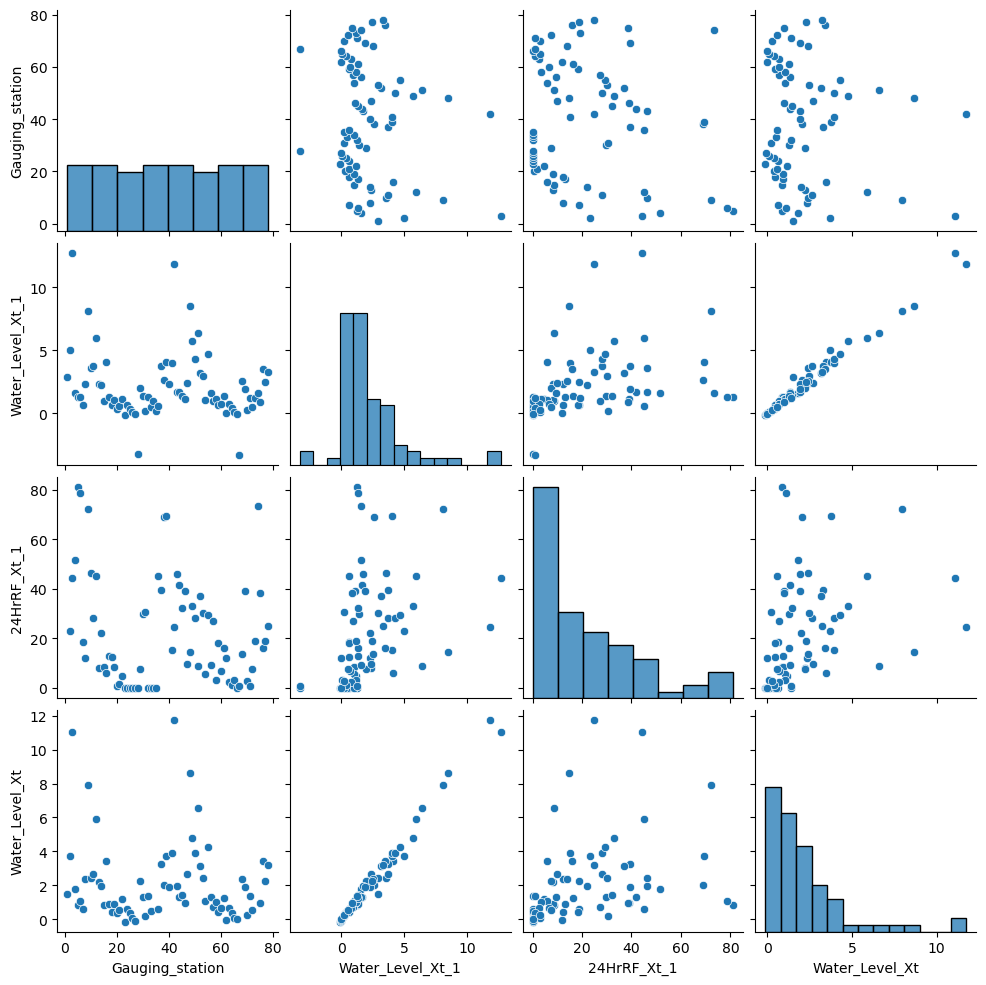

In [33]:
sns.pairplot(df)

plt.show()

In [34]:

df_clean = df.dropna(subset=["Water_Level_Xt", "24HrRF_Xt_1"]).copy()
df_clean = df_clean.drop(columns=["Gauging_station"]).reset_index(drop=True)
print(f"Rows after cleaning: {len(df_clean)}  (from {len(df)} original)")


Rows after cleaning: 70  (from 78 original)


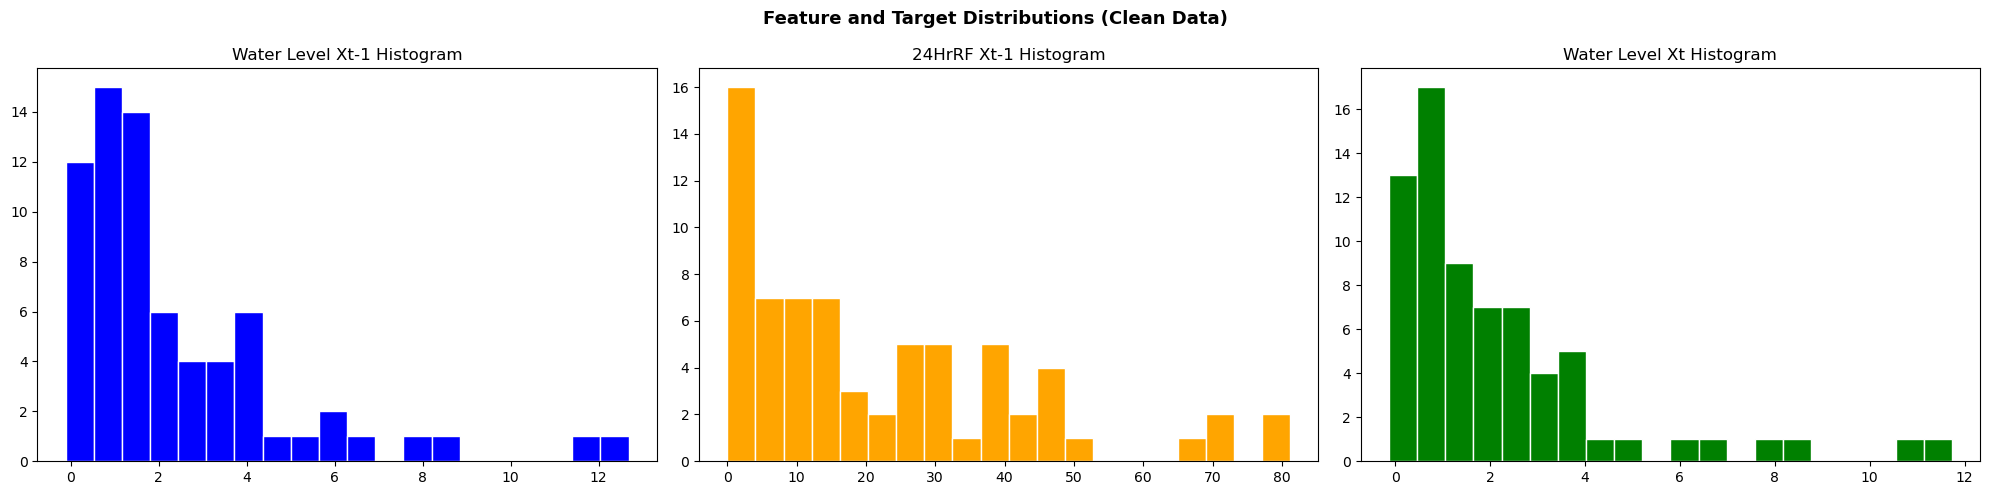

In [35]:
# Histograms on CLEAN data - what the model actually sees
fig, ax = plt.subplots(1, 3, figsize=(20, 5))
ax[0].hist(df_clean["Water_Level_Xt_1"], color="blue", edgecolor="white", bins=20)
ax[0].set_title("Water Level Xt-1 Histogram")
ax[1].hist(df_clean["24HrRF_Xt_1"], color="orange", edgecolor="white", bins=20)
ax[1].set_title("24HrRF Xt-1 Histogram")
ax[2].hist(df_clean["Water_Level_Xt"], color="green", edgecolor="white", bins=20)
ax[2].set_title("Water Level Xt Histogram")
plt.suptitle("Feature and Target Distributions (Clean Data)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


In [36]:
print(df_clean.isnull().sum())

Water_Level_Xt_1    0
24HrRF_Xt_1         0
Water_Level_Xt      0
dtype: int64


In [37]:
df_clean.corr()

,Water_Level_Xt_1,24HrRF_Xt_1,Water_Level_Xt
Water_Level_Xt_1,1.000000,0.343091,0.991670
24HrRF_Xt_1,0.343091,1.000000,0.316074
Water_Level_Xt,0.991670,0.316074,1.000000


In [38]:
from scipy.stats import skew

skew(df_clean['Water_Level_Xt_1']), skew(df_clean['24HrRF_Xt_1']), skew(df_clean['Water_Level_Xt'])

(np.float64(2.1145177814498486),
 np.float64(1.0784399436080387),
 np.float64(2.1656997701982164))

In [39]:
# Applying log transformation to the heavily skewed rainfall feature
df_clean['24HrRF_Xt_1'] = np.log1p(df_clean['24HrRF_Xt_1'])

print('Skewness after log transform:')
from scipy.stats import skew
print(skew(df_clean['24HrRF_Xt_1']))


Skewness after log transform:
-0.6932853450470946


## Outlier Analysis (Train vs Test Features)

C:\Users\asusT\AppData\Local\Temp\ipykernel_10172\1770962774.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=combined, x='Dataset', y='Water_Level_Xt_1', ax=axes[0], palette='Set2')
C:\Users\asusT\AppData\Local\Temp\ipykernel_10172\1770962774.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=combined, x='Dataset', y='24HrRF_Xt_1', ax=axes[1], palette='Set2')


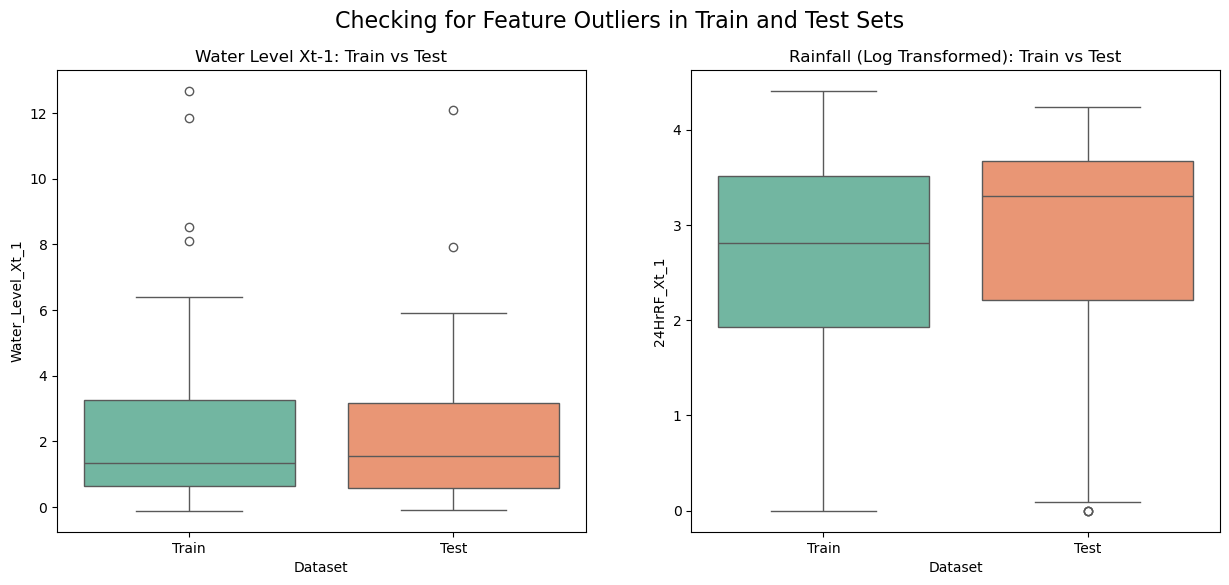

In [40]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Load test data just for visualization
if os.path.exists('sri-lanka-river-water-level-forecasting-challenge/test_data.csv'):
    test_df_viz = pd.read_csv('sri-lanka-river-water-level-forecasting-challenge/test_data.csv')
else:
    test_df_viz = pd.read_csv('test_data.csv')

# Apply the same log transform to test data
test_df_viz['24HrRF_Xt_1'] = np.log1p(test_df_viz['24HrRF_Xt_1'])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

train_viz = df_clean[['Water_Level_Xt_1', '24HrRF_Xt_1']].copy()
train_viz['Dataset'] = 'Train'

test_viz = test_df_viz[['Water_Level_Xt_1', '24HrRF_Xt_1']].copy()
test_viz['Dataset'] = 'Test'

combined = pd.concat([train_viz, test_viz])

sns.boxplot(data=combined, x='Dataset', y='Water_Level_Xt_1', ax=axes[0], palette='Set2')
axes[0].set_title('Water Level Xt-1: Train vs Test')

sns.boxplot(data=combined, x='Dataset', y='24HrRF_Xt_1', ax=axes[1], palette='Set2')
axes[1].set_title('Rainfall (Log Transformed): Train vs Test')

plt.suptitle('Checking for Feature Outliers in Train and Test Sets', fontsize=16)
plt.show()


## Model Building and Evaluation


In [41]:
x=df_clean[['Water_Level_Xt_1','24HrRF_Xt_1']]
y=df_clean['Water_Level_Xt']

print(x.shape)
print(y.shape)

(70, 2)
(70,)


In [42]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


print(x_train.shape)
print(x_test.shape) 

(56, 2)
(14, 2)


### 80/20 Train vs Test Split Feature Distributions

C:\Users\asusT\AppData\Local\Temp\ipykernel_10172\623293636.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=split_combined, x='Split', y='Water_Level_Xt_1', ax=axes[0], palette='pastel')
C:\Users\asusT\AppData\Local\Temp\ipykernel_10172\623293636.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=split_combined, x='Split', y='24HrRF_Xt_1', ax=axes[1], palette='pastel')


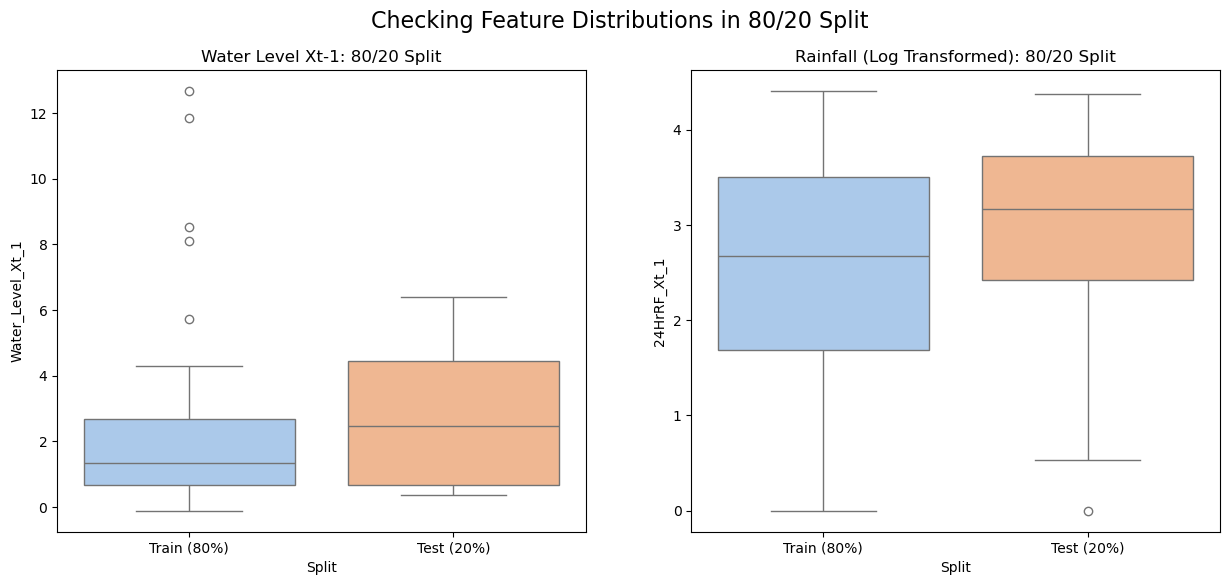

In [43]:
# Visualize the 80/20 train/test split
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

train_split_viz = x_train.copy()
train_split_viz['Split'] = 'Train (80%)'

test_split_viz = x_test.copy()
test_split_viz['Split'] = 'Test (20%)'

split_combined = pd.concat([train_split_viz, test_split_viz])

sns.boxplot(data=split_combined, x='Split', y='Water_Level_Xt_1', ax=axes[0], palette='pastel')
axes[0].set_title('Water Level Xt-1: 80/20 Split')

sns.boxplot(data=split_combined, x='Split', y='24HrRF_Xt_1', ax=axes[1], palette='pastel')
axes[1].set_title('Rainfall (Log Transformed): 80/20 Split')

plt.suptitle('Checking Feature Distributions in 80/20 Split', fontsize=16)
plt.show()


### Outlier Removal
This step filters out rows from the training set where the baseline model makes huge errors, creating a cleaner dataset.

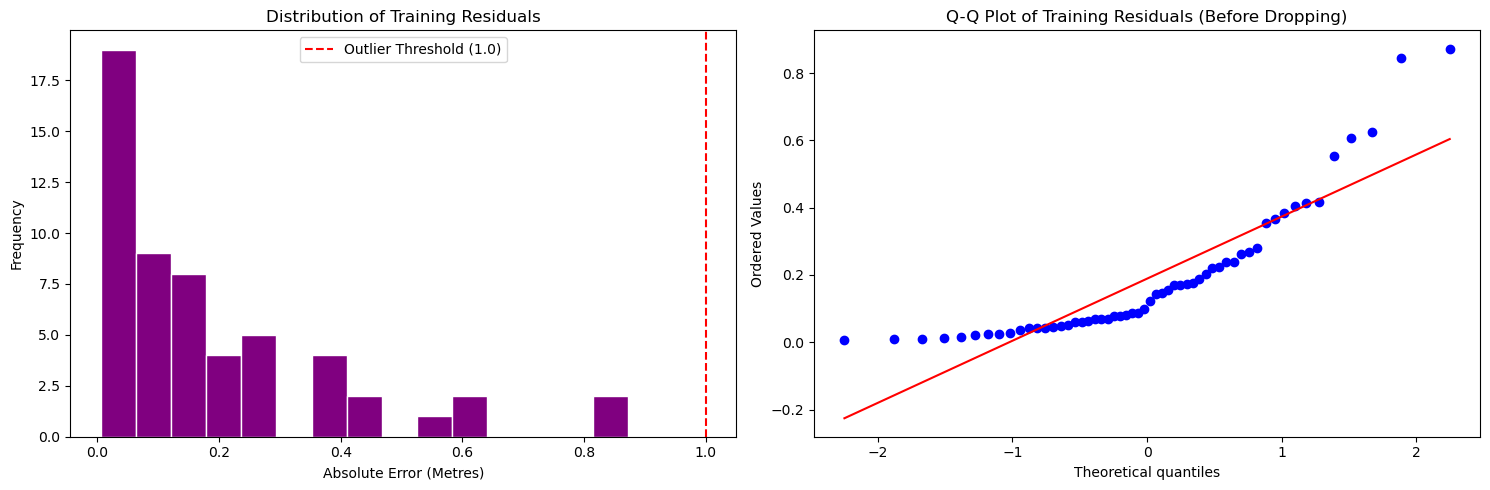

Original training rows: 56
Clean training rows : 56
Removed 0 outliers from training set.



LinearRegression()

In [44]:
# --- OUTLIER REMOVAL STEP ---
# 1. Fit a baseline model to identify outliers in the training set
baseline_model = LinearRegression()
baseline_model.fit(x_train, y_train)

# 2. Get predictions and calculate absolute residuals (errors)
baseline_preds = baseline_model.predict(x_train)
residuals = np.abs(y_train - baseline_preds)

# Visualize the residuals before dropping
from scipy.stats import probplot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(residuals, bins=15, color='purple', edgecolor='white')
axes[0].axvline(x=1.0, color='red', linestyle='--', label='Outlier Threshold (1.0)')
axes[0].set_title('Distribution of Training Residuals')
axes[0].set_xlabel('Absolute Error (Metres)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

probplot(residuals, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot of Training Residuals (Before Dropping)')

plt.tight_layout()
plt.show()

# 3. Filter out rows with unusually large errors (e.g. error > 1.0 metres)
outlier_mask = residuals < 1.0
x_train_clean = x_train[outlier_mask]
y_train_clean = y_train[outlier_mask]

print(f'Original training rows: {len(x_train)}')
print(f'Clean training rows : {len(x_train_clean)}')
print(f'Removed {len(x_train) - len(x_train_clean)} outliers from training set.\n')

# 4. Train the final model on the clean data
model = LinearRegression()
model.fit(x_train_clean, y_train_clean)


In [45]:

b0 = model.intercept_      
b1 = model.coef_[0]       
b2 = model.coef_[1]         

print(f'Intercept : {b0:.6f}')
print(f'Coef X1   : {b1:.6f}')
print(f'Coef X2   : {b2:.6f}')
print(f'\nEquation: Water_Level_Xt = {b0:.4f} + {b1:.4f}*X1 + {b2:.4f}*X2')



Intercept : 0.052514
Coef X1   : 0.944366
Coef X2   : -0.034334

Equation: Water_Level_Xt = 0.0525 + 0.9444*X1 + -0.0343*X2


In [46]:
y_pred=model.predict(x_test)
y_actual=y_test

residuals=y_actual-y_pred
residuals_df=pd.DataFrame({'Actual':y_actual,'Predicted':y_pred,'Residuals':residuals}).sort_index()
print(residuals_df)

    Actual  Predicted  Residuals
0     3.71   4.664941  -0.954941
4     1.10   1.139307  -0.039307
5     0.61   0.545301   0.064699
9     2.65   3.449822  -0.799822
10    5.90   5.521074   0.378926
12    1.99   2.078976  -0.088976
18    0.37   0.364823   0.005177
22    0.62   0.647464  -0.027464
31    0.58   0.487679   0.092321
33    2.02   2.409213  -0.389213
45    6.56   6.018090   0.541910
49    4.27   4.354913  -0.084913
54    0.69   0.671374   0.018626
67    3.42   3.241428   0.178572


In [47]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

r2   = r2_score(y_actual, y_pred)
mae  = mean_absolute_error(y_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))

print("=" * 40)
print("  MODEL PERFORMANCE METRICS")
print("=" * 40)
print(f"  R2   : {r2:.4f}  ")
print(f"  MAE  : {mae:.4f}  <- avg error in metres")
print(f"  RMSE : {rmse:.4f}  <- penalises large errors more")
print("=" * 40)



  MODEL PERFORMANCE METRICS
  R2   : 0.9596  
  MAE  : 0.2618  <- avg error in metres
  RMSE : 0.3967  <- penalises large errors more


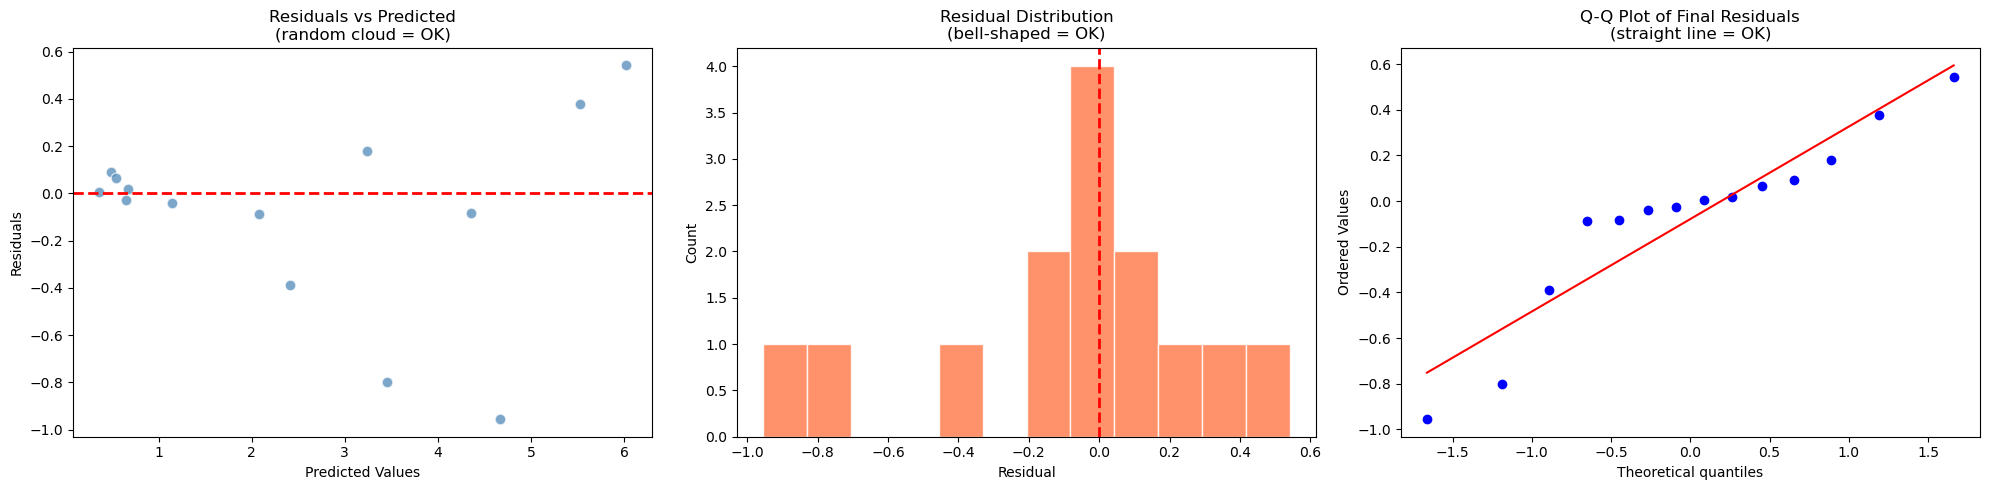

In [48]:
from scipy.stats import shapiro, probplot

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Plot 1: Residuals vs Predicted (checks heteroscedasticity)
axes[0].scatter(y_pred, residuals, alpha=0.7, color='steelblue', edgecolors='white', s=60)
axes[0].axhline(0, color='red', lw=2, linestyle='--')
axes[0].set_xlabel('Predicted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Predicted\n(random cloud = OK)')

# Plot 2: Histogram of residuals (checks normality)
axes[1].hist(residuals, bins=12, color='coral', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', lw=2, linestyle='--')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution\n(bell-shaped = OK)')

# Plot 3: Q-Q Plot (checks normality)
probplot(residuals, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot of Final Residuals\n(straight line = OK)')

plt.tight_layout()
plt.show()


In [49]:
import os

if os.path.exists('sri-lanka-river-water-level-forecasting-challenge/test_data.csv'):
    test_df = pd.read_csv('sri-lanka-river-water-level-forecasting-challenge/test_data.csv')
else:
    test_df = pd.read_csv('test_data.csv')

# Apply the same log transformation to the test set
test_df['24HrRF_Xt_1'] = np.log1p(test_df['24HrRF_Xt_1'])

x_test_final = test_df[['Water_Level_Xt_1', '24HrRF_Xt_1']]
prediction = model.predict(x_test_final)

submission_df = pd.DataFrame({
    'ID': test_df['Gauging_station'],
    'Water_Level_Xt': prediction
})

submission_df.to_csv('submission_v3.csv', index=False)


In [23]:
submission_df.to_csv('submission_v2.csv',index=False)